## **Linear Regression from Scratch: **

Implementation of Gradient Descent & Quadratic Cost

Linear Regression: The "Hard Way"In this lab, we implement Linear Regression without using libraries like Scikit-Learn. We will derive the gradients of the Quadratic Cost Function and update our parameters manually.1. The HypothesisFor a single feature $x$, our model is:$$\hat{y} = mx + b$$2. The Quadratic Cost Function (Mean Squared Error)We measure the error $J$ as the average of the squared differences:$$J(m, b) = \frac{1}{2n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$3. The Gradients (Partial Derivatives)To minimize $J$, we find how the cost changes with respect to $m$ and $b$:$$\frac{\partial J}{\partial m} = \frac{1}{n} \sum (mx_i + b - y_i) \cdot x_i$$


$$\frac{\partial J}{\partial b} = \frac{1}{n} \sum (mx_i + b - y_i)$$

## **Lab Observations**

Convergence: Observe the "Cost Convergence" plot. Why does the cost drop rapidly at first and then flatten out? (Hint: The gradient gets smaller as we approach the minimum).

Learning Rate Sensitivity: If you change lr to 2.0, the cost will explode. This is because the "step" is so large that the optimizer overshoots the minimum and climbs the other side of the "bowl."

From-Scratch vs. Libraries: In a library like PyTorch, the error * X step is handled automatically via AutoGrad, but the underlying math remains exactly the same as what you wrote above.

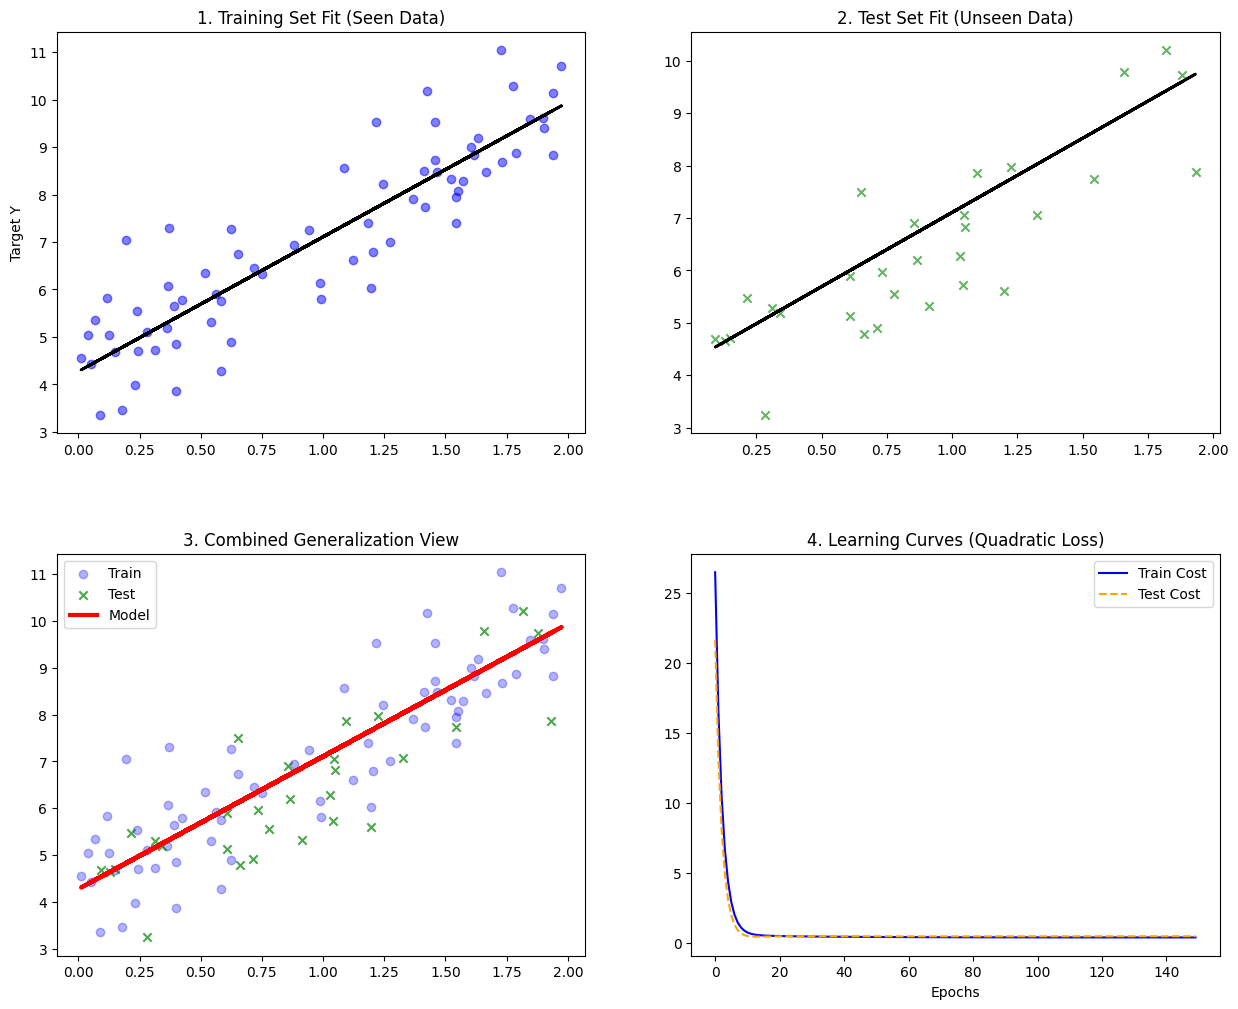

Final Weights: m=2.834, b=4.274
Train MSE: 0.3852 | Test MSE: 0.4716


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. DATA GENERATION & MANUAL SPLIT (70/30) ---
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

indices = np.arange(100)
np.random.shuffle(indices)
train_idx, test_idx = indices[:70], indices[70:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

# --- 2. GRADIENT DESCENT FROM SCRATCH ---
m, b = 0.0, 0.0
lr = 0.1
epochs = 150
n_train, n_test = float(len(X_train)), float(len(X_test))

train_costs, test_costs = [], []

for i in range(epochs):
    # Forward Pass & Cost Calculation
    y_train_pred = m * X_train + b
    y_test_pred = m * X_test + b

    train_costs.append((1 / (2 * n_train)) * np.sum((y_train_pred - y_train)**2))
    test_costs.append((1 / (2 * n_test)) * np.sum((y_test_pred - y_test)**2))

    # Gradient Calculation (Training Data ONLY)
    dm = (1 / n_train) * np.sum((y_train_pred - y_train) * X_train)
    db = (1 / n_train) * np.sum(y_train_pred - y_train)

    # Update Parameters
    m -= lr * dm
    b -= lr * db

# --- 3. COMPREHENSIVE VISUALIZATION ---
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.3)

# Plot A: Training Set Only
axs[0, 0].scatter(X_train, y_train, color='blue', alpha=0.5)
axs[0, 0].plot(X_train, m * X_train + b, color='black', lw=2)
axs[0, 0].set_title("1. Training Set Fit (Seen Data)")
axs[0, 0].set_ylabel("Target Y")

# Plot B: Test Set Only
axs[0, 1].scatter(X_test, y_test, color='green', alpha=0.6, marker='x')
axs[0, 1].plot(X_test, m * X_test + b, color='black', lw=2)
axs[0, 1].set_title("2. Test Set Fit (Unseen Data)")

# Plot C: Combined Visualization
axs[1, 0].scatter(X_train, y_train, color='blue', alpha=0.3, label="Train")
axs[1, 0].scatter(X_test, y_test, color='green', alpha=0.7, marker='x', label="Test")
axs[1, 0].plot(X, m * X + b, color='red', lw=3, label="Model")
axs[1, 0].set_title("3. Combined Generalization View")
axs[1, 0].legend()

# Plot D: Learning Curves (Cost vs Epochs)
axs[1, 1].plot(range(epochs), train_costs, color='blue', label="Train Cost")
axs[1, 1].plot(range(epochs), test_costs, color='orange', linestyle='--', label="Test Cost")
axs[1, 1].set_title("4. Learning Curves (Quadratic Loss)")
axs[1, 1].set_xlabel("Epochs")
axs[1, 1].legend()

plt.show()

print(f"Final Weights: m={m:.3f}, b={b:.3f}")
print(f"Train MSE: {train_costs[-1]:.4f} | Test MSE: {test_costs[-1]:.4f}")